# Basic KV Cache Correctness & Performance benchmark:

This notebook implements a basic benchmark for KVCache that shows,
- Correctness : no-cache vs KV-cache token equivalence under fixed seed
- Performance metrics : end-to-end latency, decode latency (ms/token), throughput (tokens/sec) 

In [ ]:
pip install torch transformers matplotlib

In [ ]:
import sys
import os
import torch
import time
import random
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel 
from transformers import GPT2Tokenizer

# Add the parent directory to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))

from model.gpt import GPT, GPTConfig, load_hf_weights
from inference.generate import generate

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

def set_seed(seed: int = 1234):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


In [ ]:
# Load HF pretrained weights
hf_model = GPT2LMHeadModel.from_pretrained("gpt2")
hf_model.eval()

# Match the configuration of the pre-trained GPT-2 model
config = GPTConfig(
	vocab_size=50257,  # Match GPT-2 vocab size
	n_embd=768,        # Match GPT-2 embedding size
	n_layer=12,        # Match GPT-2 number of layers
	n_head=12         # Match GPT-2 number of attention heads
)
model = GPT(config).to(device)
load_hf_weights(model, hf_model)
model.eval()


In [5]:
seed = 400

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
prompt = "Once upon a time"
max_new_tokens = 50
input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

set_seed(seed)
start_time_1 = time.time()
output_no_cache = generate(model, input_ids.clone(), max_new_tokens=max_new_tokens, use_kv_cache=False)
end_time_1 = time.time()

set_seed(seed)
start_time_2 = time.time()
output_cache = generate(model, input_ids.clone(), max_new_tokens=max_new_tokens, use_kv_cache=True)
end_time_2 = time.time()

match = torch.equal(output_no_cache, output_cache)
print(f"Outputs match: {match}")

print("Without KV cache:")
print("Output:", tokenizer.decode(output_no_cache[0], skip_special_tokens=True))
print(f"End-to-end latency: {end_time_1 - start_time_1:.2f} seconds")
print(f"Decode ms per token: {(end_time_1 - start_time_1) / max_new_tokens * 1000:.2f} ms/token")
print(f"Throughput: {max_new_tokens / (end_time_1 - start_time_1):.2f} tokens/sec\n")


print("With KV cache:")
print("Output:", tokenizer.decode(output_cache[0], skip_special_tokens=True))
print(f"End-to-end latency: {end_time_2 - start_time_2:.2f} seconds")
print(f"Decode ms per token: {(end_time_2 - start_time_2) / max_new_tokens * 1000:.2f} ms/token")
print(f"Throughput: {max_new_tokens / (end_time_2 - start_time_2):.2f} tokens/sec")





Outputs match: True
Without KV cache:
Output: Once upon a time it seemed that airmanship had become opaque and all-and-or-nothing, and that major military interventions were preparing future military chaos. Over those interweaves of murder, the spectre of peacetime opportunity and financial peril became better seen.
End-to-end latency: 2.52 seconds
Decode ms per token: 50.37 ms/token
Throughput: 19.85 tokens/sec

With KV cache:
Output: Once upon a time it seemed that airmanship had become opaque and all-and-or-nothing, and that major military interventions were preparing future military chaos. Over those interweaves of murder, the spectre of peacetime opportunity and financial peril became better seen.
End-to-end latency: 0.83 seconds
Decode ms per token: 16.56 ms/token
Throughput: 60.38 tokens/sec


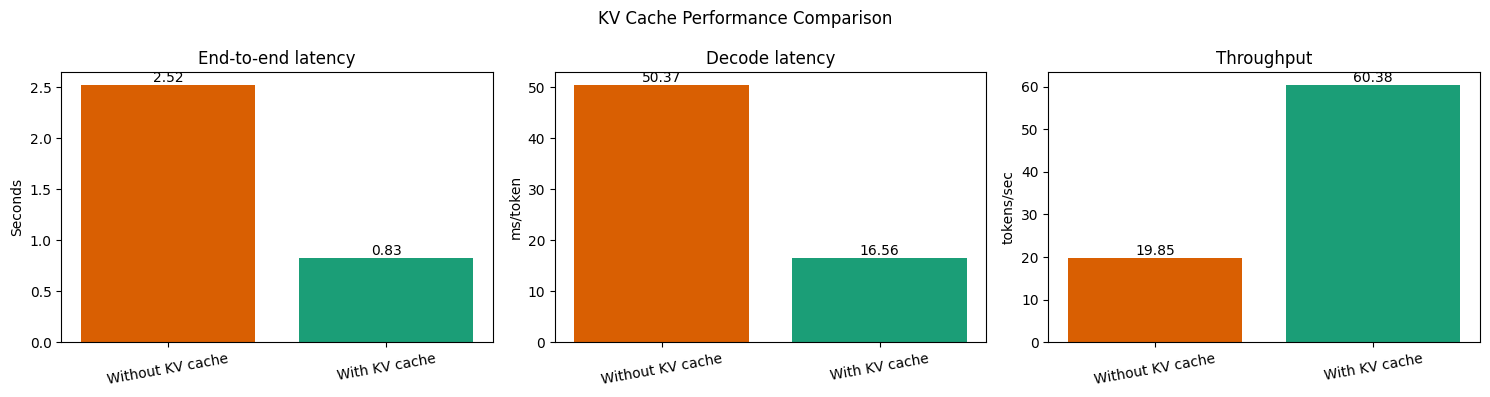

In [7]:
labels = ["Without KV cache", "With KV cache"]
latencies = [end_time_1 - start_time_1, end_time_2 - start_time_2]
decode_ms = [latency / max_new_tokens * 1000 for latency in latencies]
throughputs = [max_new_tokens / latency for latency in latencies]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["#d95f02", "#1b9e77"]
metrics = [
    (latencies, "End-to-end latency", "Seconds"),
    (decode_ms, "Decode latency", "ms/token"),
    (throughputs, "Throughput", "tokens/sec"),
]

for ax, (values, title, ylabel) in zip(axes, metrics):
    bars = ax.bar(labels, values, color=colors)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=10)
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2f}",
            ha="center",
            va="bottom",
        )

fig.suptitle("KV Cache Performance Comparison")
fig.tight_layout()
plt.show()
